### Functional equivalence evaluation

In [12]:
# Loading necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
import skimage.io as io
import imageio.v3 as iio
import tifffile
import json
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]

### Functions for plotting

In [2]:

## Mean Squared Error (MSE) function for comparing two images
def mse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))

## Heatmap function for visualizing differences between two images
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels, ha="center", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels, va="center", rotation_mode="anchor")

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


## Percentile stretch function for normalizing image contrast
def percentile_stretch(img, low=1, high=99):
    """Stretch image contrast to given percentile range."""
    vmin = np.percentile(img, low)
    vmax = np.percentile(img, high)
    return img, vmin, vmax

style for plots:

In [17]:
LABEL_FONTSIZE  = 14   # channel row labels
TITLE_FONTSIZE  = 14   # column/panel titles
CBAR_FONTSIZE   = 14    # colorbar labels
ANNOT_FONTSIZE  = 10    # in-image annotations
SUPTITLE_COLOR  = "#222222"
LABEL_COLOR     = "#333333"


### Create MSE matrix for all pairwise 30 replicate runs of numorph and nf-core/lsmquant

All pair wise mse is calculated for stitched images between numorph and nf-core/lsmquant. The calculated matrices are saved to csv to perform calculations once

In [1]:
CHANNEL = ["C1", "C2"] # C1: topro, C2: ctip2
matlab_dir = "/mnt/ssd/performance_benchmark/matlab"
nextflow_dir = "/mnt/ssd/performance_benchmark/nextflow"

mse_matrix = [i,j]
for i in range(len(replicate_indices)):
    mat_volumeC1 = read_img_vol(mat_rep{i}_stitch_volumeC1_filelist)
    for j in range(len(replicate_indices)):
        next_volumeC1 = read_img_vol(next_rep{j}_stitch_volumeC1_filelist)
        mse_matrix[i,j] = mse(mat_volumeC1, next_volumeC1)

In [2]:
# read matlab images from the output of the benchmark
#Returns {channel: [ [slice_paths for run 0], [slice_paths for run 1], … ]}
mat_img_dict = {"C1": [], "C2": []}
for i in replicate_indices:
    file_pattern_C1 = f"{matlab_dir}/replicate_{i}/stitched/sample{i}_*_C1_*.tif"
    file_pattern_C2 = f"{matlab_dir}/replicate_{i}/stitched/sample{i}_*_C2_*.tif"
    C1_files = glob.glob(file_pattern_C1)
    C1_files.sort()  # Sort the file paths to ensure consistent order
    C2_files = glob.glob(file_pattern_C2)
    C2_files.sort()  # Sort the file paths to ensure consistent order
    mat_img_dict["C1"].append(C1_files)
    mat_img_dict["C2"].append(C2_files)
    print(f"Replicate {i}: Found {len(C1_files)} C1 files and {len(C2_files)} C2 files.")

print(mat_img_dict["C1"]) 


NameError: name 'replicate_indices' is not defined

In [ ]:
nextflow_img_dict = {"C1": [], "C2": []}
for i in replicate_indices:
    file_pattern_C1 = f"{nextflow_dir}/replicate_{i}/numorphstitch/TEST1/stitched/TEST1_*_C1_*.tif"
    file_pattern_C2 = f"{nextflow_dir}/replicate_{i}/numorphstitch/TEST1/stitched/TEST1_*_C2_*.tif"
    C1_files = glob.glob(file_pattern_C1)
    C1_files.sort()  # Sort the file paths to ensure consistent order
    C2_files = glob.glob(file_pattern_C2)
    C2_files.sort()  # Sort the file paths to ensure consistent order
    nextflow_img_dict["C1"].append(C1_files)
    nextflow_img_dict["C2"].append(C2_files)
    print(f"Replicate {i}: Found {len(C1_files)} C1 files and {len(C2_files)} C2 files.")

print(nextflow_img_dict["C1"])

In [ ]:
# create empty matrix to store the MSE values for each pair of replicates
mse_matrix_C1 = np.zeros((len(replicate_indices), len(replicate_indices)))
mse_matrix_C2 = np.zeros((len(replicate_indices), len(replicate_indices)))

In [ ]:
for i in range(len(replicate_indices)):
    mat_C1_vol = io.imread_collection(mat_img_dict["C1"][i]).concatenate()
    for j in range(len(replicate_indices)):
        nextflow_C1_vol = io.imread_collection(nextflow_img_dict["C1"][j]).concatenate()
        mse_matrix_C1[i, j] = mse(mat_C1_vol, nextflow_C1_vol)

In [ ]:
# save mse matrix to csv 
mse_df_C1 = pd.DataFrame(mse_matrix_C1, index=replicate_indices, columns=replicate_indices)
mse_df_C1.to_csv("/mnt/ssd/performance_benchmark/mse_matrix_C1.csv")

In [ ]:
# mse matrix for c2 
for i in range(len(replicate_indices)):
    mat_C2_vol = io.imread_collection(mat_img_dict["C2"][i]).concatenate()
    for j in range(len(replicate_indices)):
        nextflow_C2_vol = io.imread_collection(nextflow_img_dict["C2"][j]).concatenate()
        mse_matrix_C2[i, j] = mse(mat_C2_vol, nextflow_C2_vol)

In [ ]:
mse_df_C2 = pd.DataFrame(mse_matrix_C2, index=replicate_indices, columns=replicate_indices)
mse_df_C2.to_csv("/mnt/ssd/performance_benchmark/mse_matrix_C2.csv")

### Plot comparison for the 30 pipeline runs 

In [21]:
#read in mse matricesfrom csv
mse_df_C1 = pd.read_csv("/mnt/ssd/performance_benchmark/mse_matrix_C1.csv", index_col=0)
mse_df_C2 = pd.read_csv("/mnt/ssd/performance_benchmark/mse_matrix_C2.csv", index_col=0)

In [4]:
# display example stitched images 
# numoprh replicate 08
# nextflow replicate 21
numorph_img_ctip2_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/matlab/replicate_08/stitched/sample08_0009_C2_ctip2_stitched.tif")
lsmquant_img_ctip2_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/nextflow/replicate_21/numorphstitch/TEST1/stitched/TEST1_0009_C2_ctip2_stitched.tif")

numorph_img_topro_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/matlab/replicate_08/stitched/sample08_0009_C1_topro_stitched.tif") 
lsmquant_img_topro_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/nextflow/replicate_21/numorphstitch/TEST1/stitched/TEST1_0009_C1_topro_stitched.tif")

In [6]:
# calculate mse and difference between the two images
mse_ctip2 = mse(numorph_img_ctip2_z0009, lsmquant_img_ctip2_z0009)
diff_ctip2 = np.abs(numorph_img_ctip2_z0009.astype(np.float64) - lsmquant_img_ctip2_z0009.astype(np.float64))
mse_topro = mse(numorph_img_topro_z0009, lsmquant_img_topro_z0009)
diff_topro = np.abs(numorph_img_topro_z0009.astype(np.float64) - lsmquant_img_topro_z0009.astype(np.float64))   

In [6]:
# ctip2
_, vmin_nmctip, vmax_nmctip = percentile_stretch(numorph_img_ctip2_z0009, low=1, high=99)
_, vmin_lqctip, vmax_lqctip = percentile_stretch(lsmquant_img_ctip2_z0009, low=1, high=99)

# topro
_, vmin_nmtopro, vmax_nmtopro = percentile_stretch(numorph_img_topro_z0009, low=1, high=99)
_, vmin_lqtopro, vmax_lqtopro = percentile_stretch(lsmquant_img_topro_z0009, low=1, high=99)

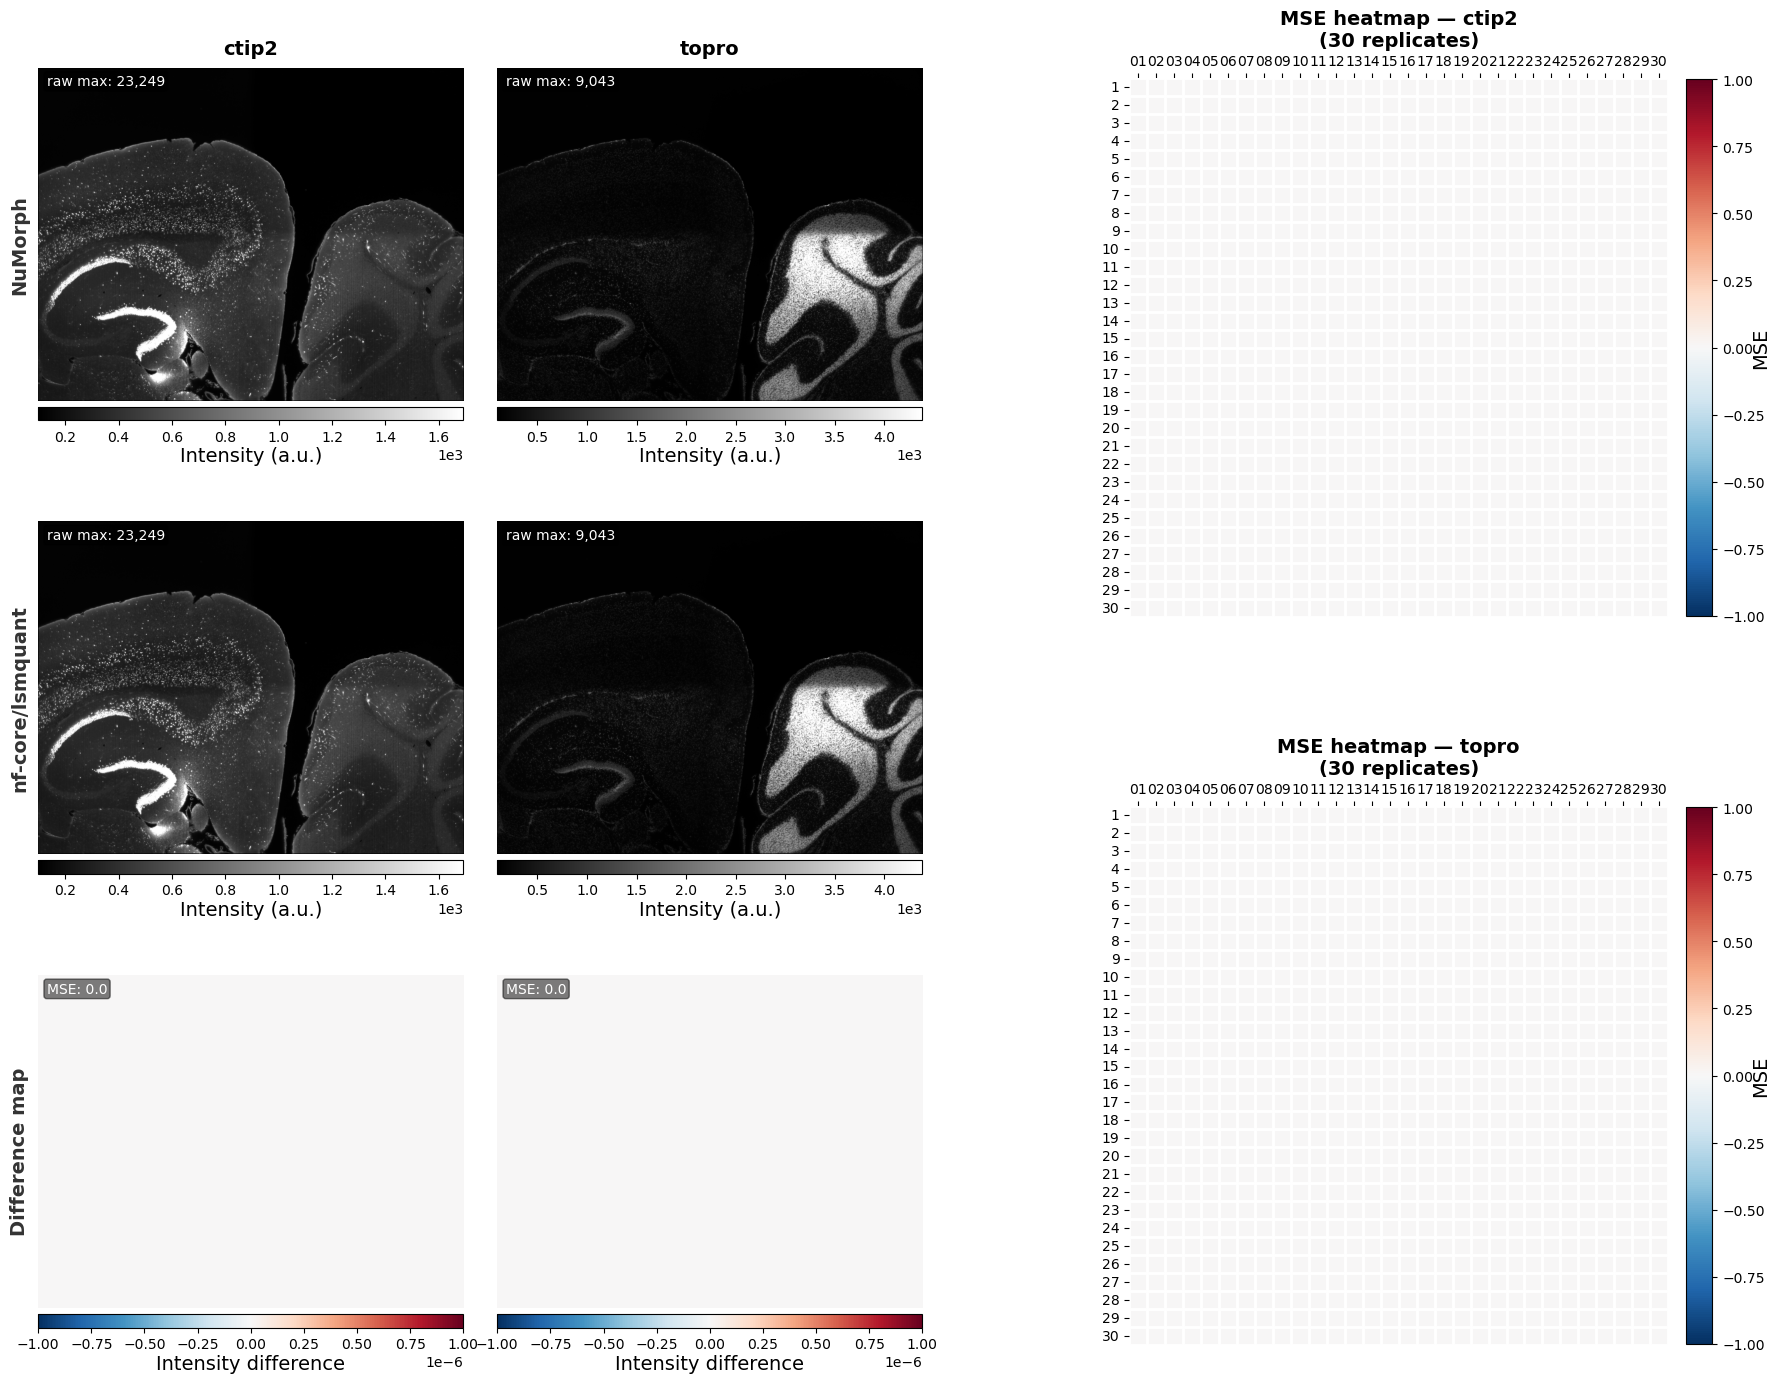

In [30]:
# ── channel definitions ────────────────────────────────────────────────────────
channels = [
    {
        "name":    "ctip2",
        "img_nm":  rot90_ccw(numorph_img_ctip2_z0009),
        "img_lsm": rot90_ccw(lsmquant_img_ctip2_z0009),
        "diff":    rot90_ccw(diff_ctip2),
        "mse":     mse_ctip2,
        "mse_df":  mse_df_C1,
    },
    {
        "name":    "topro",
        "img_nm":  rot90_ccw(numorph_img_topro_z0009),
        "img_lsm": rot90_ccw(lsmquant_img_topro_z0009),
        "diff":    rot90_ccw(diff_topro),
        "mse":     mse_topro,
        "mse_df":  mse_df_C2,
    },
]
 
# ── shared vmin/vmax per channel ───────────────────────────────────────────────
def percentile_stretch(img, low=1, high=99):
    return np.percentile(img, low), np.percentile(img, high)
 
for ch in channels:
    ch["vmin"], ch["vmax"] = percentile_stretch(ch["img_nm"])
 
row_labels = ["NuMorph", "nf-core/lsmquant", "Difference map"]
 
# ── top-level figure: 2 subfigures side by side ───────────────────────────────
# Left subfig  → 3×2 image grid  (width_ratio 2)
# Right subfig → 2 stacked heatmaps (width_ratio 1)
fig = plt.figure(figsize=(19, 14))
fig.patch.set_facecolor("white")
 
sf_left, sf_right = fig.subfigures(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.02,
)
 
# ══════════════════════════════════════════════════════════════════════════════
# LEFT SUBFIGURE — image grid (unchanged logic)
# ══════════════════════════════════════════════════════════════════════════════
gs_left = gridspec.GridSpec(
    3, 2,
    figure=sf_left,
    hspace=0.04,
    wspace=0.08,
    left=0.04, right=0.98,
    top=0.98, bottom=0.02,
)
 
for col_idx, ch in enumerate(channels):
    for row_idx in range(3):
 
        ax_img = sf_left.add_subplot(gs_left[row_idx, col_idx])
 
        if row_idx == 0:
            img, vmin, vmax = ch["img_nm"], ch["vmin"], ch["vmax"]
            cmap, clabel, norm = "gray", "Intensity (a.u.)", None
        elif row_idx == 1:
            img, vmin, vmax = ch["img_lsm"], ch["vmin"], ch["vmax"]
            cmap, clabel, norm = "gray", "Intensity (a.u.)", None
        else:
            diff_abs_max = np.percentile(np.abs(ch["diff"]), 99.5)
            if diff_abs_max < 1e-6:
                diff_abs_max = 1e-6
            img   = ch["diff"]
            vmin, vmax = -diff_abs_max, diff_abs_max
            cmap  = "RdBu_r"
            clabel = "Intensity difference"
            norm  = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
 
        im = ax_img.imshow(
            img, cmap=cmap,
            **({"norm": norm} if norm else {"vmin": vmin, "vmax": vmax}),
            interpolation="antialiased",
        )
        ax_img.axis("off")
 
        # annotations
        if row_idx < 2:
            ax_img.text(
                0.02, 0.98, f"raw max: {int(np.max(img)):,}",
                transform=ax_img.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
        else:
            ax_img.text(
                0.02, 0.98, f"MSE: {ch['mse']}",
                transform=ax_img.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
 
        # colorbar glued below image
        divider = make_axes_locatable(ax_img)
        cbar_ax = divider.append_axes("bottom", size="4%", pad=0.06)
        cb = sf_left.colorbar(im, cax=cbar_ax, orientation="horizontal")
        cb.set_label(clabel, fontsize=CBAR_FONTSIZE, labelpad=2)
        cb.ax.tick_params(labelsize=ANNOT_FONTSIZE)
        cb.formatter.set_powerlimits((0, 0))
        cb.update_ticks()
 
        # row labels on leftmost column
        if col_idx == 0:
            slot = gs_left[row_idx, 0].get_position(sf_left)
            sf_left.text(
                0.01, slot.y0 + slot.height / 2,
                row_labels[row_idx],
                fontsize=LABEL_FONTSIZE, fontweight="bold",
                ha="left", va="center", rotation=90, color=LABEL_COLOR,
            )
 
        # column titles on top row
        if row_idx == 0:
            ax_img.set_title(ch["name"], fontsize=TITLE_FONTSIZE,
                             fontweight="bold", pad=10)
 
# ══════════════════════════════════════════════════════════════════════════════
# RIGHT SUBFIGURE — stacked MSE heatmaps
# ══════════════════════════════════════════════════════════════════════════════
gs_right = gridspec.GridSpec(
    2, 1,
    figure=sf_right,
    hspace=0.30,
    left=0.18, right=0.80,
    top=0.95, bottom=0.03,
)
 
for hm_idx, ch in enumerate(channels):
    ax_hm = sf_right.add_subplot(gs_right[hm_idx, 0])
 
    df   = ch["mse_df"]
    data = df.values.astype(float)
 
    hm_abs_max = np.nanpercentile(np.abs(data), 99.5)
    if hm_abs_max < 1e-9:
        hm_abs_max = 1e-9
 
    im_hm, cbar_hm = heatmap(
        data,
        row_labels=df.index,
        col_labels=df.columns,
        ax=ax_hm,
        cmap="RdBu_r",
        vmin=-hm_abs_max,
        vmax=hm_abs_max,
        cbarlabel="MSE",
        cbar_kw={"fraction": 0.046, "pad": 0.03},
    )
    cbar_hm.ax.tick_params(labelsize=ANNOT_FONTSIZE)
    cbar_hm.ax.yaxis.label.set_fontsize(CBAR_FONTSIZE)
    cbar_hm.ax.yaxis.get_offset_text().set_visible(False)
    cbar_hm.formatter.set_powerlimits((0, 0))
    cbar_hm.update_ticks()
    ax_hm.tick_params(axis="both", labelsize=ANNOT_FONTSIZE)
    ax_hm.set_title(
        f"MSE heatmap — {ch['name']}\n(30 replicates)",
        fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6,
    )

 
plt.savefig("zslice_rotated.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()


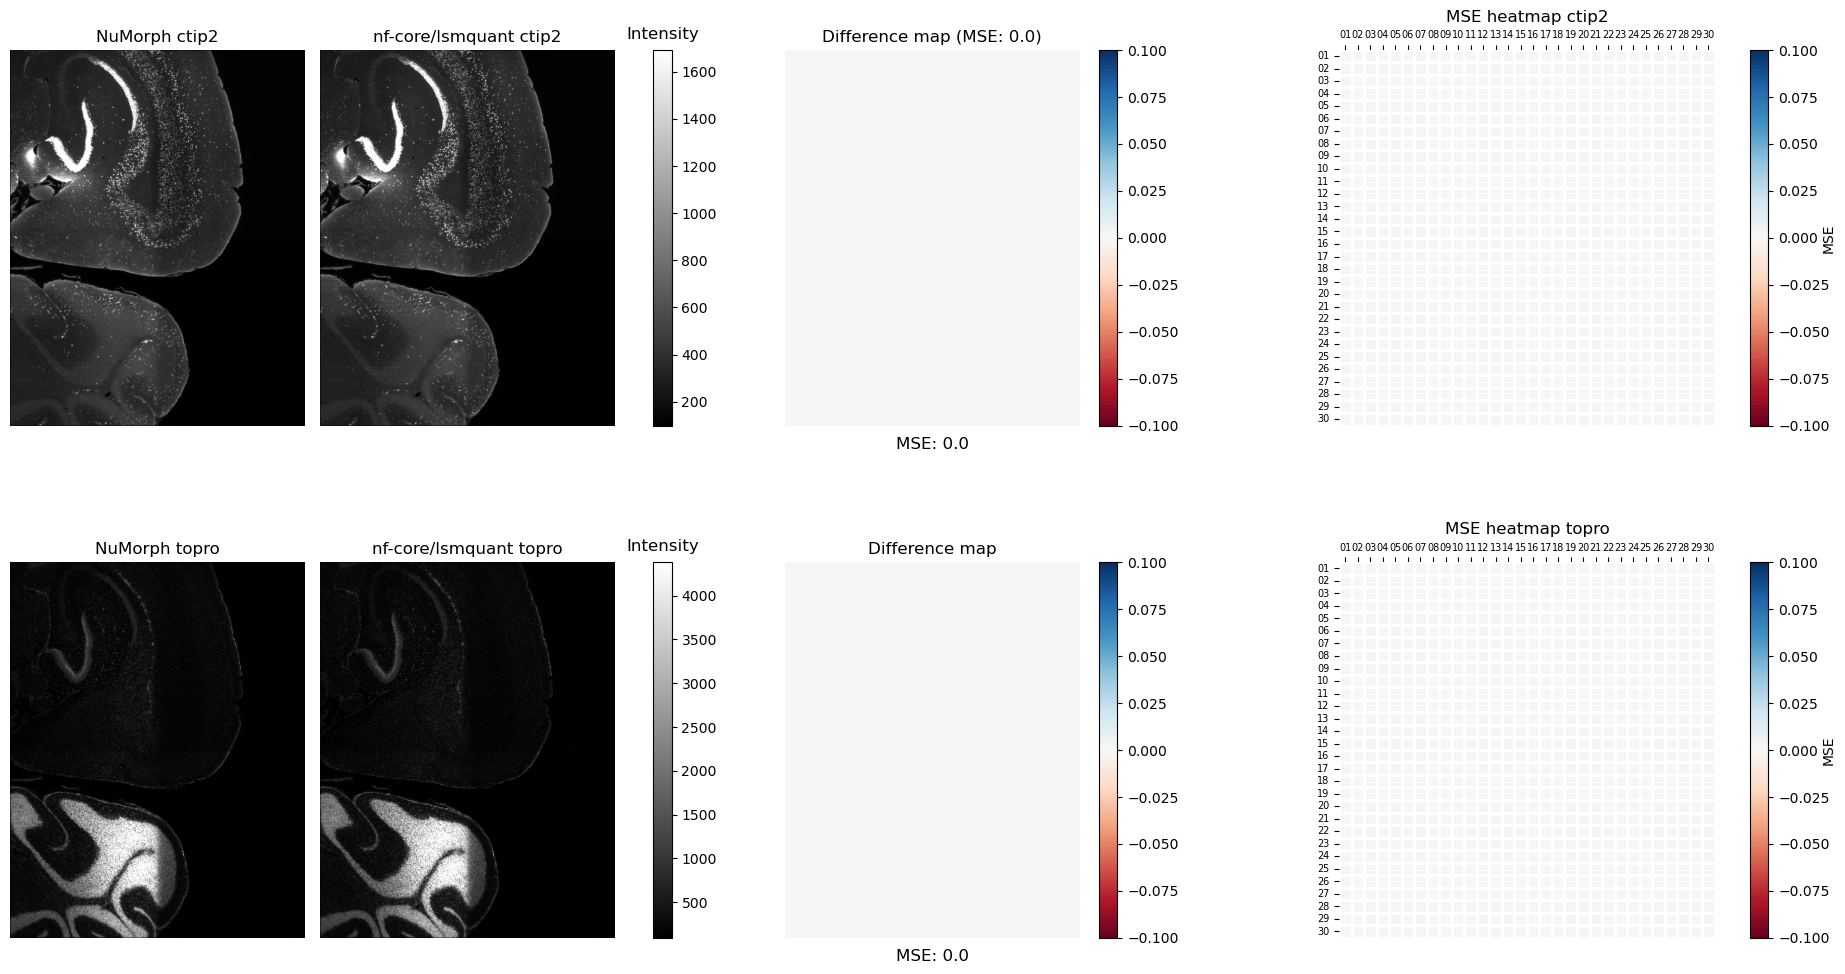

In [7]:
fig = plt.figure(figsize=(24, 10))
subfigs = fig.subfigures(2, 1, hspace=0.05)

# ── Row 0: ctip2 ──────────────────────────────────────────────────────────────
axes0 = subfigs[0].subplots(
    1, 4,
    gridspec_kw={"width_ratios": [1, 1, 1, 1.8], "wspace": 0.0}
)

im0 = axes0[0].imshow(numorph_img_ctip2_z0009, cmap="gray", vmin=vmin_nmctip, vmax=vmax_nmctip)
axes0[0].set_title("NuMorph ctip2")
axes0[0].axis("off")

im1 = axes0[1].imshow(lsmquant_img_ctip2_z0009, cmap="gray", vmin=vmin_lqctip, vmax=vmax_lqctip)
axes0[1].set_title("nf-core/lsmquant ctip2")
axes0[1].axis("off")
#subfigs[0].colorbar(im1, ax=axes0[:2], label="Intensity")
cbar0 = subfigs[0].colorbar(im1, ax=axes0[:2])
cbar0.ax.set_title("Intensity", pad=8)

im2 = axes0[2].imshow(diff_ctip2, cmap="RdBu")
axes0[2].set_title(f"Difference map (MSE: {mse_ctip2})")
axes0[2].axis("off")
subfigs[0].colorbar(im2, ax=axes0[2])
axes0[2].text(0.5, -0.05, f"MSE: {mse_ctip2}", transform=axes0[2].transAxes,
              ha="center", va="center", fontsize=12, color="black")

# Heatmap for ctip2
im_heat0, cbar_heat0 = heatmap(
    mse_df_C1, mse_df_C1.columns, mse_df_C1.columns,
    ax=axes0[3], cmap="RdBu", cbarlabel="MSE"
)
axes0[3].tick_params(axis='both', labelsize=7)  # ← add this after heatmap call
axes0[3].set_title("MSE heatmap ctip2")

# ── Row 1: topro ──────────────────────────────────────────────────────────────
axes1 = subfigs[1].subplots(
    1, 4,
    gridspec_kw={"width_ratios": [1, 1, 1, 1.8], "wspace": 0.0}
)

im3 = axes1[0].imshow(numorph_img_topro_z0009, cmap="gray", vmin=vmin_nmtopro, vmax=vmax_nmtopro)
axes1[0].set_title("NuMorph topro")
axes1[0].axis("off")

im4 = axes1[1].imshow(lsmquant_img_topro_z0009, cmap="gray", vmin=vmin_lqtopro, vmax=vmax_lqtopro)
axes1[1].set_title("nf-core/lsmquant topro")
axes1[1].axis("off")
#subfigs[1].colorbar(im4, ax=axes1[:2], label="Intensity")
cbar1 = subfigs[1].colorbar(im4, ax=axes1[:2])
cbar1.ax.set_title("Intensity", pad=8)

im5 = axes1[2].imshow(diff_topro, cmap="RdBu")
axes1[2].set_title("Difference map")
axes1[2].axis("off")
subfigs[1].colorbar(im5, ax=axes1[2])
axes1[2].text(0.5, -0.05, f"MSE: {mse_topro}", transform=axes1[2].transAxes,
              ha="center", va="center", fontsize=12, color="black")

# Heatmap for topro
im_heat1, cbar_heat1 = heatmap(
    mse_df_C2, mse_df_C2.columns, mse_df_C2.columns,
    ax=axes1[3], cmap="RdBu", cbarlabel="MSE"
)
axes1[3].tick_params(axis='both', labelsize=7)
axes1[3].set_title("MSE heatmap topro")

plt.show()

#### adjusted plot

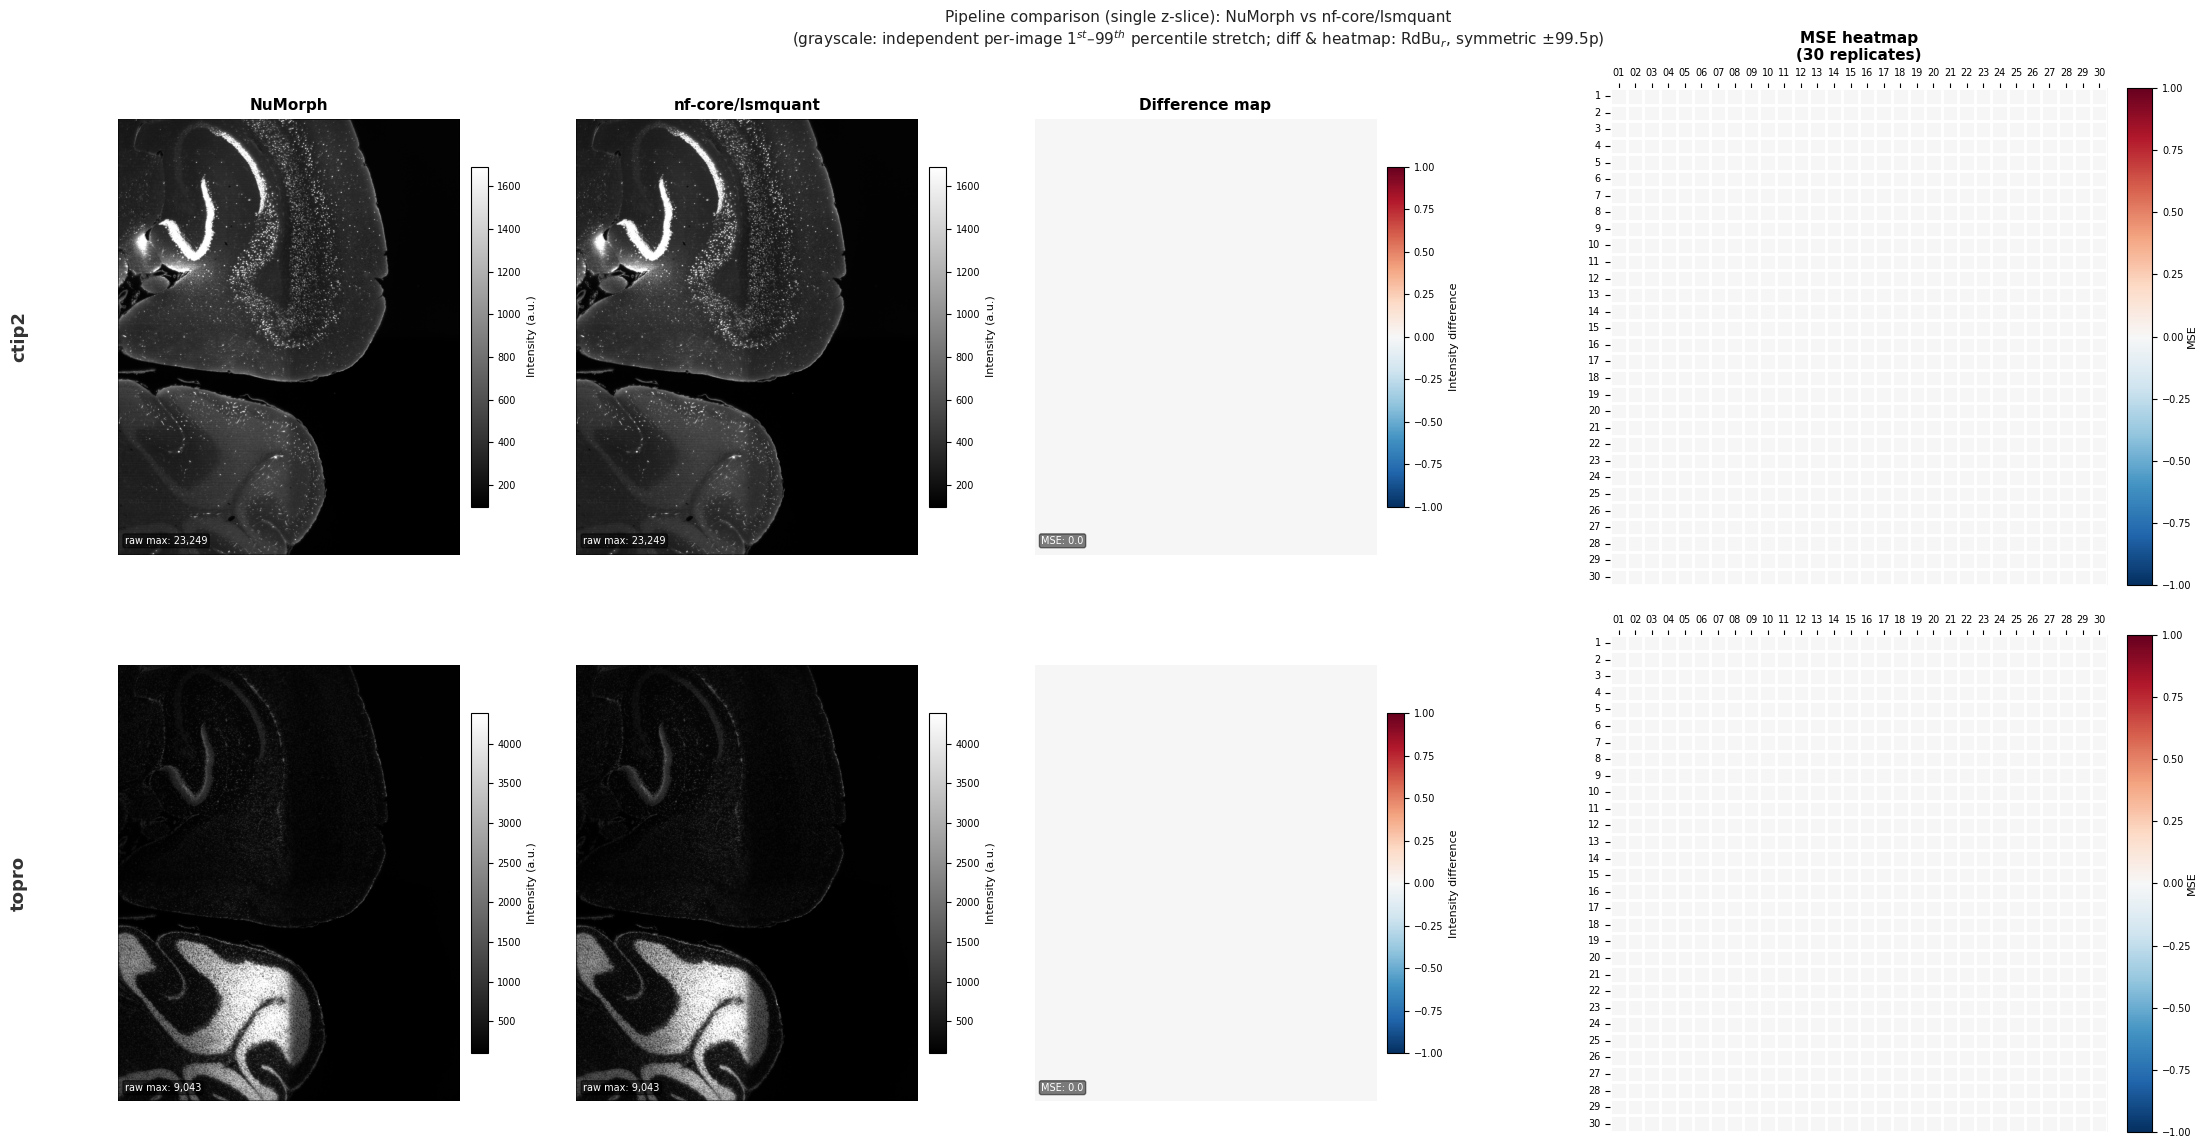

In [ ]:
# variable to store all the relevant data for each channel for easy access when plotting
rows = [
    {
        "name":       "ctip2",
        "img_nm":     numorph_img_ctip2_z0009,
        "img_lsm":    lsmquant_img_ctip2_z0009,
        "vmin_nm":    vmin_nmctip,
        "vmax_nm":    vmax_nmctip,
        "vmin_lsm":   vmin_lqctip,
        "vmax_lsm":   vmax_lqctip,
        "diff":       diff_ctip2,
        "mse":        mse_ctip2,
        "mse_df":     mse_df_C1,
    },
    {
        "name":       "topro",
        "img_nm":     numorph_img_topro_z0009,
        "img_lsm":    lsmquant_img_topro_z0009,
        "vmin_nm":    vmin_nmtopro,
        "vmax_nm":    vmax_nmtopro,
        "vmin_lsm":   vmin_lqtopro,
        "vmax_lsm":   vmax_lqtopro,
        "diff":       diff_topro,
        "mse":        mse_topro,
        "mse_df":     mse_df_C2,
    },
]
 
col_titles = [
    "NuMorph",
    "nf-core/lsmquant",
    "Difference map",
    "MSE heatmap\n(30 replicates)",
]
 
# ── figure & GridSpec ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 12))
fig.patch.set_facecolor("white")
 
gs = gridspec.GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1, 1, 1, 1.8],
    hspace=0.10,
    wspace=0.2,
    left=0.05, right=0.90,
    top=0.91, bottom=0.04,
)
 
# ── plot ───────────────────────────────────────────────────────────────────────
for row_idx, ch in enumerate(rows):
 
    # ── diverging norm for diff map ──
    diff_abs_max = np.percentile(np.abs(ch["diff"]), 99.5)
    if diff_abs_max < 1e-6:
        diff_norm = TwoSlopeNorm(vmin=-1e-6, vcenter=0, vmax=1e-6)
        diff_abs_max = 1e-6
    else:
        diff_norm = TwoSlopeNorm(
            vmin=-diff_abs_max, vcenter=0, vmax=diff_abs_max
        )

    for col_idx in range(4):
        ax = fig.add_subplot(gs[row_idx, col_idx])
 
        # ── col 0: NuMorph ──
        if col_idx == 0:
            im = ax.imshow(
                ch["img_nm"], cmap="gray",
                vmin=ch["vmin_nm"], vmax=ch["vmax_nm"])
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, shrink=0.88)
            cb.set_label("Intensity (a.u.)", fontsize=CBAR_FONTSIZE)
            cb.ax.tick_params(labelsize=ANNOT_FONTSIZE)
            # raw max annotation
            raw_max = int(np.max(ch["img_nm"]))
            ax.text(
                0.02, 0.02, f"raw max: {raw_max:,}",
                transform=ax.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
 
        # ── col 1: nf-core/lsmquant ──
        elif col_idx == 1:
            im = ax.imshow(
                ch["img_lsm"], cmap="gray",
                vmin=ch["vmin_lsm"], vmax=ch["vmax_lsm"])
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity (a.u.)", fontsize=CBAR_FONTSIZE)
            cb.ax.tick_params(labelsize=ANNOT_FONTSIZE)
            # raw max annotation
            raw_max = int(np.max(ch["img_lsm"]))
            ax.text(
                0.02, 0.02, f"raw max: {raw_max:,}",
                transform=ax.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
 
        # ── col 2: difference map ──
        elif col_idx == 2:
            im = ax.imshow(
                ch["diff"], cmap="RdBu_r", norm=diff_norm)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity difference", fontsize=CBAR_FONTSIZE)
            cb.ax.tick_params(labelsize=ANNOT_FONTSIZE)
            cb.ax.yaxis.get_offset_text().set_visible(False)
            cb.formatter.set_powerlimits((0, 0))
            cb.update_ticks()

            # MSE annotation
            ax.text(
                0.02, 0.02, f"MSE: {ch['mse']}",
                transform=ax.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
 
        # ── col 3: MSE heatmap ──
        else:
            df = ch["mse_df"]
            data = df.values.astype(float)
 
            # Symmetric diverging scale centred on 0
            hm_abs_max = np.nanpercentile(np.abs(data), 99.5)
            if hm_abs_max < 1e-9:
                hm_abs_max = 1e-9
 
            im, cbar_hm = heatmap(
                data,
                row_labels=df.index,
                col_labels=df.columns,
                ax=ax,
                cmap="RdBu_r",
                vmin=-hm_abs_max,
                vmax=hm_abs_max,
                cbarlabel="MSE",
                cbar_kw={"fraction": 0.046, "pad": 0.03},
            )
            cbar_hm.ax.tick_params(labelsize=ANNOT_FONTSIZE)
            cbar_hm.ax.yaxis.label.set_fontsize(CBAR_FONTSIZE)
            cbar_hm.ax.yaxis.get_offset_text().set_visible(False)
            cbar_hm.formatter.set_powerlimits((0, 0))
            cbar_hm.update_ticks()
            ax.tick_params(axis="both", labelsize=ANNOT_FONTSIZE)

 
        # ── column titles (first row only) ──
        if row_idx == 0:
            ax.set_title(
                col_titles[col_idx],
                fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6,
            )
 
        # turn off axes for image panels only; heatmap (col 3) keeps ticks
        if col_idx < 3:
            ax.axis("off")
 
    # ── channel row label (left margin, matching large-brain plot style) ──
    slot_pos = gs[row_idx, 0].get_position(fig)
    fig.text(
        0.005,
        slot_pos.y0 + slot_pos.height / 2,
        ch["name"],
        fontsize=LABEL_FONTSIZE, fontweight="bold",
        ha="left", va="center", rotation=90,
        color=LABEL_COLOR,
    )
 
 
plt.savefig("zslice_comparison.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()


## Comparison of stitched out put for a full mouse. brain dataset 


In [9]:
# output comparison stitched images for the large dataset


lsmquant_stitched_path = "/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out/numorphstitch/L73D766P9/stitched"
#lsmquant_stitched_path = "/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_newmonitor/stitched"
#lsmquant_stitched_path = "/mnt/ssd/numorph_full_datasets/pair15/output_L73D766P9/remove"

lsmquant_507_C1_topro = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_0506_C1_topro_stitched.tif")
print(lsmquant_stitched_path + "/L73D766P9_0506_C1_topro_stitched.tif")
lsmquant_507_C3_ctip2 = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_0506_C3_ctip2_stitched.tif")
lsmquant_507_C2_brn2 = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_0506_C2_brn2_stitched.tif")

#numorph_stitched_path = "/mnt/ssd/numorph_full_datasets/pair15/output_L73D766P9/remove"

numorph_stitched_path = "/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_newmonitor/stitched"

numorph_507_C1_topro = tifffile.imread(numorph_stitched_path + "/L73D766P9_0506_C1_topro_stitched.tif")
print(numorph_stitched_path + "/L73D766P9_0506_C1_topro_stitched.tif")
numorph_507_C3_ctip2 = tifffile.imread(numorph_stitched_path + "/L73D766P9_0506_C3_ctip2_stitched.tif")
numorph_507_C2_brn2 = tifffile.imread(numorph_stitched_path + "/L73D766P9_0506_C2_brn2_stitched.tif")

/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out/numorphstitch/L73D766P9/stitched/L73D766P9_0506_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_newmonitor/stitched/L73D766P9_0506_C1_topro_stitched.tif


In [ ]:
# display example stitched images for the large dataset
# i have 3 channels and for each 3 images ( numoprh, lsmquant, difference)
# so i want to have a 3 row, 3 column figure where each row is a channel and each column is numoprh, lsmquant, difference

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
# --- Row 0: topro ---
axes[0, 0].imshow(numorph_507_C1_topro, cmap="gray",vmax=numorph_507_C1_topro.max(), vmin=numorph_507_C1_topro.min())
axes[0, 0].set_title("NuMorph topro")
axes[0, 0].axis("off")
cbar1_topro = fig.colorbar(axes[0, 0].imshow(numorph_507_C1_topro, cmap="gray"), ax=axes[0, 0])
cbar1_topro.set_label("Intensity")

axes[0, 1].imshow(lsmquant_507_C1_topro, cmap="gray",vmax=lsmquant_507_C1_topro.max(), vmin=lsmquant_507_C1_topro.min())
axes[0, 1].set_title("nf-core/lsmquant topro")
axes[0, 1].axis("off")
cbar2_topro = fig.colorbar(axes[0, 1].imshow(lsmquant_507_C1_topro, cmap="gray"), ax=axes[0, 1])
cbar2_topro.set_label("Intensity")

diff_topro_large = numorph_507_C1_topro - lsmquant_507_C1_topro
im_diff_topro = axes[0, 2].imshow(diff_topro_large, cmap="viridis")
axes[0, 2].set_title("Difference map topro")
axes[0, 2].axis("off")
cbar_topro = fig.colorbar(im_diff_topro, ax=axes[0, 2])
cbar_topro.set_label("Intensity Difference")    

# --- Row 1: ctip2 ---
axes[1, 0].imshow(numorph_507_C3_ctip2, cmap="gray",vmax=numorph_507_C3_ctip2.max(), vmin=numorph_507_C3_ctip2.min())
axes[1, 0].set_title("NuMorph ctip2")
axes[1, 0].axis("off")
cbar1_ctip2 = fig.colorbar(axes[1, 0].imshow(numorph_507_C3_ctip2, cmap="gray"), ax=axes[1, 0])
cbar1_ctip2.set_label("Intensity")

axes[1, 1].imshow(lsmquant_507_C3_ctip2, cmap="gray",vmax=lsmquant_507_C3_ctip2.max(), vmin=lsmquant_507_C3_ctip2.min())
axes[1, 1].set_title("nf-core/lsmquant ctip2")
axes[1, 1].axis("off")
cbar2_ctip2 = fig.colorbar(axes[1, 1].imshow(lsmquant_507_C3_ctip2, cmap="gray"), ax=axes[1, 1])
cbar2_ctip2.set_label("Intensity")

diff_ctip2_large = numorph_507_C3_ctip2 - lsmquant_507_C3_ctip2
im_diff_ctip2 = axes[1, 2].imshow(diff_ctip2_large, cmap="viridis")
axes[1, 2].set_title("Difference map ctip2")
axes[1, 2].axis("off")
cbar_ctip2 = fig.colorbar(im_diff_ctip2, ax=axes[1, 2])
cbar_ctip2.set_label("Intensity Difference")

# --- Row 2: brn2 ---
axes[2, 0].imshow(numorph_507_C2_brn2, cmap="gray",vmax=numorph_507_C2_brn2.max(), vmin=numorph_507_C2_brn2.min())
axes[2, 0].set_title("NuMorph brn2")
axes[2, 0].axis("off")
cbar1_brn2 = fig.colorbar(axes[2, 0].imshow(numorph_507_C2_brn2, cmap="gray"), ax=axes[2, 0])
cbar1_brn2.set_label("Intensity")

axes[2, 1].imshow(lsmquant_507_C2_brn2, cmap="gray",vmax=lsmquant_507_C2_brn2.max(), vmin=lsmquant_507_C2_brn2.min())
axes[2, 1].set_title("nf-core/lsmquant brn2")
axes[2, 1].axis("off")
cbar2_brn2 = fig.colorbar(axes[2, 1].imshow(lsmquant_507_C2_brn2, cmap="gray"), ax=axes[2, 1])
cbar2_brn2.set_label("Intensity")


diff_brn2_large = numorph_507_C2_brn2 - lsmquant_507_C2_brn2
im_diff_brn2 = axes[2, 2].imshow(diff_brn2_large, cmap="viridis")
axes[2, 2].set_title("Difference map brn2")
axes[2, 2].axis("off")
cbar3_brn2 = fig.colorbar(im_diff_brn2, ax=axes[2, 2])
cbar3_brn2.set_label("Intensity Difference")

plt.tight_layout()
plt.show()


In [10]:
channels = [
    {
        "name":    "topro",
        "numorph": numorph_507_C1_topro,
        "lsm":     lsmquant_507_C1_topro,
    },
    {
        "name":    "ctip2",
        "numorph": numorph_507_C3_ctip2,
        "lsm":     lsmquant_507_C3_ctip2,
    },
    {
        "name":    "brn2",
        "numorph": numorph_507_C2_brn2,
        "lsm":     lsmquant_507_C2_brn2,
    },
]


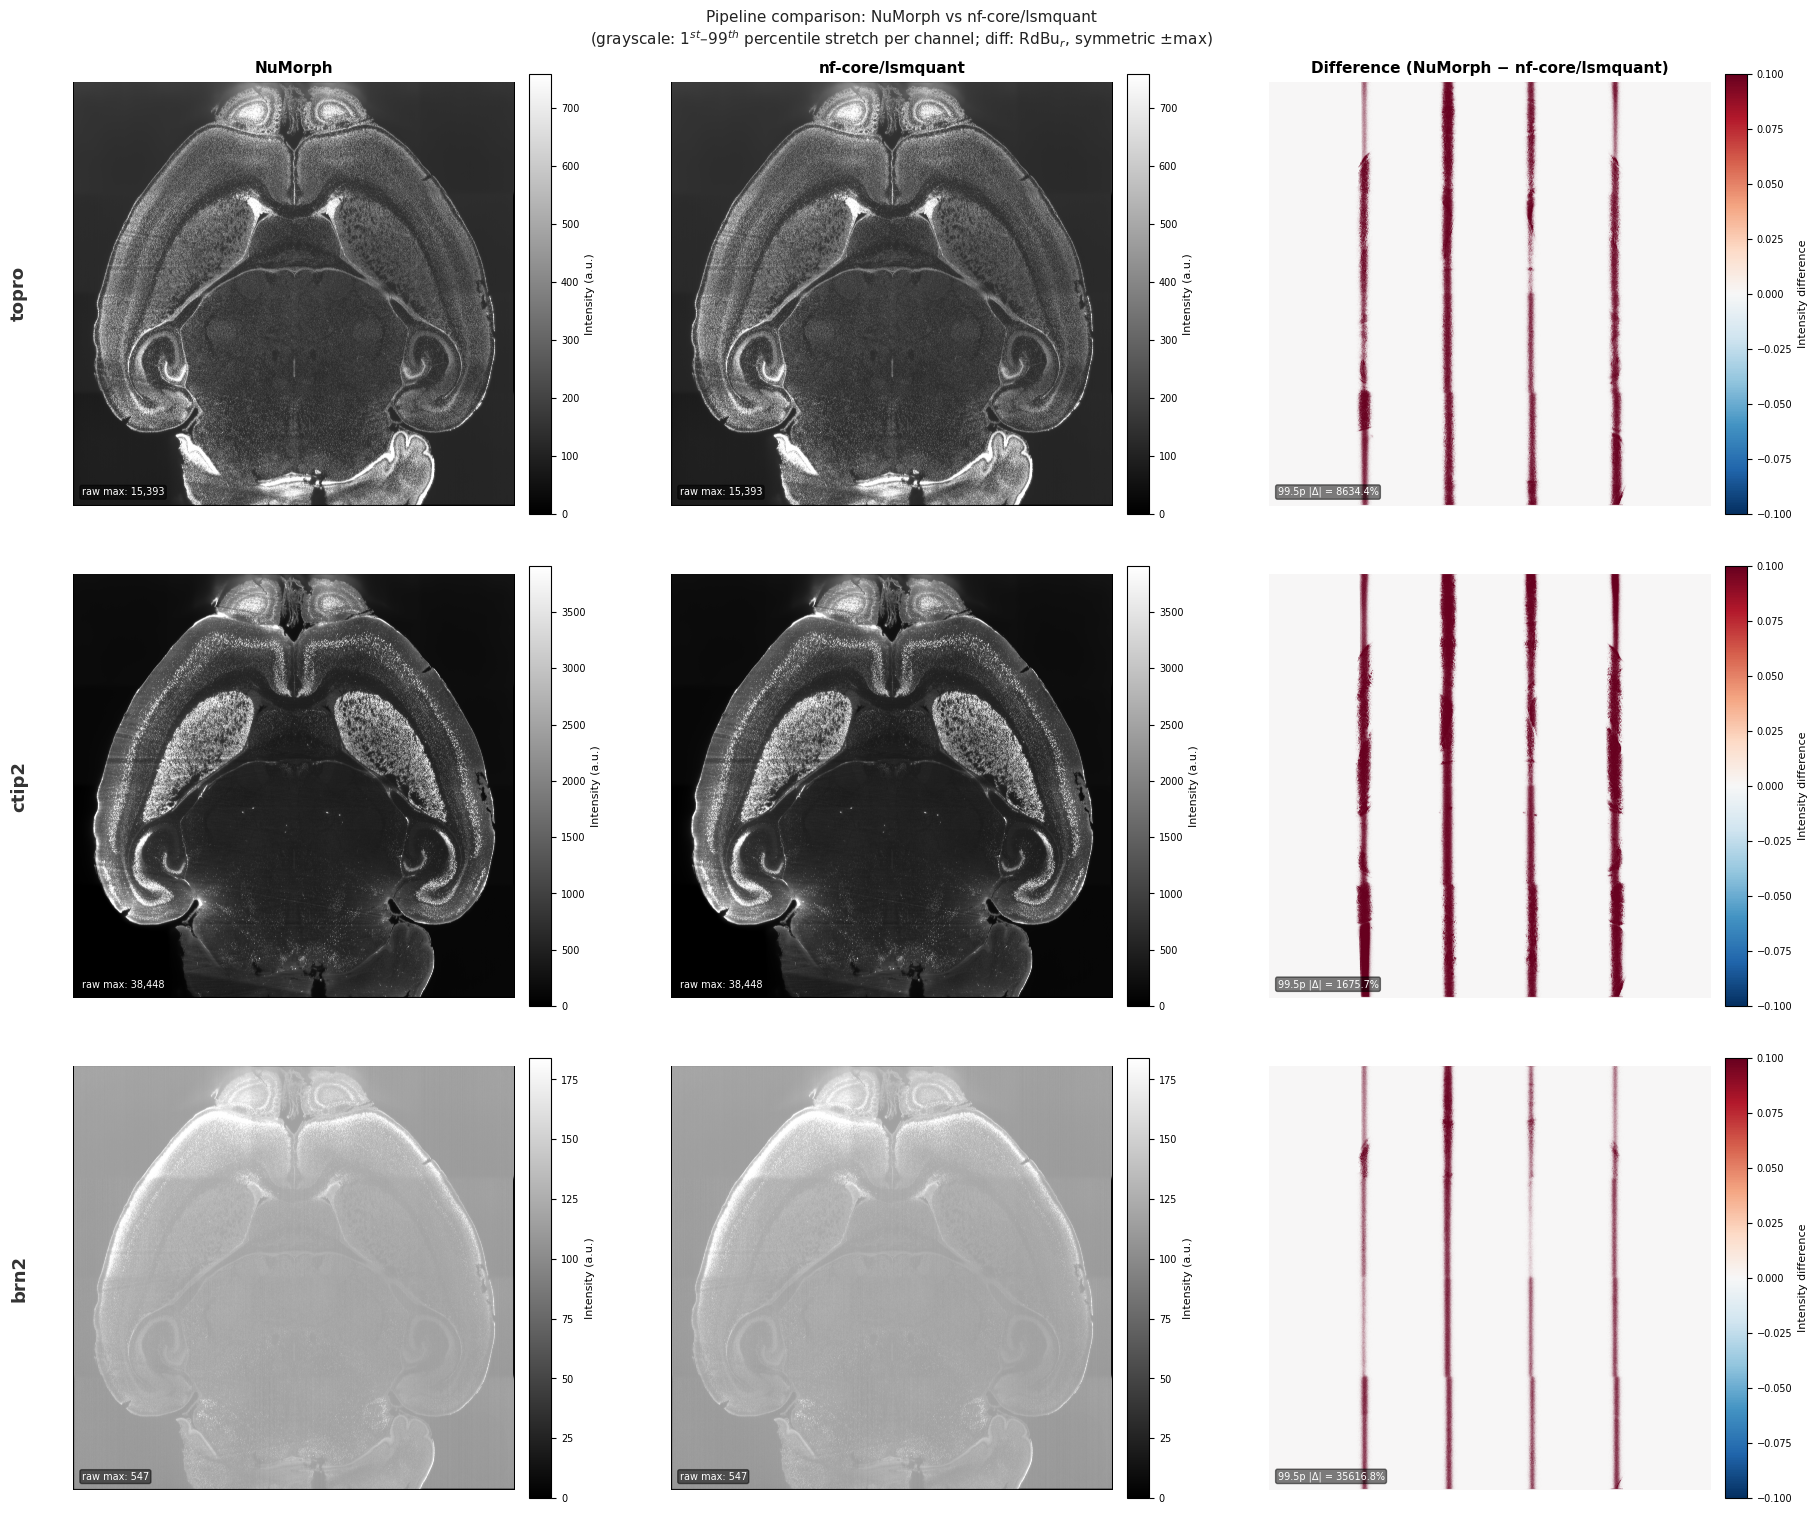

In [11]:
# ── figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor("white")
 
# Use GridSpec for tighter control over spacing
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.08,   # tight vertical gap between rows
    wspace=0.25,   # room for colorbars
    left=0.04, right=0.97,
    top=0.94, bottom=0.04,
)
 
col_titles = ["NuMorph", "nf-core/lsmquant", "Difference (NuMorph − nf-core/lsmquant)"]
 
# ── plot ───────────────────────────────────────────────────────────────────────
for row, ch in enumerate(channels):
    img_nm  = ch["numorph"]
    img_lsm = ch["lsm"]
    diff    = img_nm - img_lsm
 
    # Per-channel percentile stretch (same limits for both pipelines so they
    # are directly comparable within a row)
    _, vmin, vmax = percentile_stretch(img_nm, low=1, high=99)
 
    # Difference colormap: diverging, symmetric around 0
    # Use the actual data range (capped at ±0.1 as in original) so small
    # differences don't get artificially amplified
    diff_abs_max = min(np.percentile(np.abs(diff), 99.5), 0.10)
    if diff_abs_max < 1e-6:
        # Images are effectively identical — use a tiny symmetric range
        # and the diff map will appear uniformly white (centered)
        diff_norm = TwoSlopeNorm(vmin=-1e-6, vcenter=0, vmax=1e-6)
    else:
        diff_norm = TwoSlopeNorm(vmin=-diff_abs_max, vcenter=0, vmax=diff_abs_max)
 
    for col in range(3):
        ax = fig.add_subplot(gs[row, col])
 
        # ── column 0: NuMorph ──
        if col == 0:
            im = ax.imshow(img_nm, cmap="gray", vmin=vmin, vmax=vmax)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity (a.u.)", fontsize=8)
            cb.ax.tick_params(labelsize=7)
            # Annotate the raw max so the reader sees the true scale
            raw_max = int(np.max(img_nm))
            ax.text(0.02, 0.02, f"raw max: {raw_max:,}",
                    transform=ax.transAxes, fontsize=7,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
 
        # ── column 1: nf-core/lsmquant ──
        elif col == 1:
            im = ax.imshow(img_lsm, cmap="gray", vmin=vmin, vmax=vmax)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity (a.u.)", fontsize=8)
            cb.ax.tick_params(labelsize=7)
            # Annotate the raw max so the reader sees the true scale
            raw_max = int(np.max(img_lsm))
            ax.text(0.02, 0.02, f"raw max: {raw_max:,}",
                    transform=ax.transAxes, fontsize=7,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
 
        # ── column 2: difference map ──
        else:
            im = ax.imshow(diff, cmap="RdBu_r", norm=diff_norm)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity difference", fontsize=8)
            cb.ax.tick_params(labelsize=7)
            # Annotate max absolute difference as % of channel range
            pct = 100 * np.percentile(np.abs(diff), 99.5) / (vmax - vmin) if (vmax - vmin) > 0 else 0
            ax.text(0.02, 0.02, f"99.5p |Δ| = {pct:.1f}%",
                    transform=ax.transAxes, fontsize=7,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
 
        ax.axis("off")
 
        # Column titles on first row only
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11, fontweight="bold", pad=6)
 
        # Channel label on left side of col 0
        if col == 0:
            ax.set_ylabel(ch["name"], fontsize=11, fontweight="bold",
                          rotation=90, labelpad=6)
            ax.yaxis.set_label_position("left")
            ax.axis("off")   # keep axis off but ylabel still renders via text
            # Use fig.text for reliable positioning
            fig.text(
                0.005,
                # vertically centre within this row's GridSpec slot
                gs[row, 0].get_position(fig).y0 +
                gs[row, 0].get_position(fig).height / 2,
                ch["name"],
                fontsize=13, fontweight="bold",
                ha="left", va="center", rotation=90,
                color="#333333",
            )
 
# ── overall title ──────────────────────────────────────────────────────────────
fig.suptitle(
    "Pipeline comparison: NuMorph vs nf-core/lsmquant\n"
    r"(grayscale: 1$^{st}$–99$^{th}$ percentile stretch per channel; "
    r"diff: RdBu$_r$, symmetric ±max)",
    fontsize=11, y=0.975, color="#222222",
)
 
plt.savefig("pipeline_comparison.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
